=== Original Graph ===
Nodes: 100
Edges: 371

=== Sparse Graph ===
Nodes: 100
Edges: 111

Original Avg Degree : 7.42
Sparse Avg Degree   : 2.22


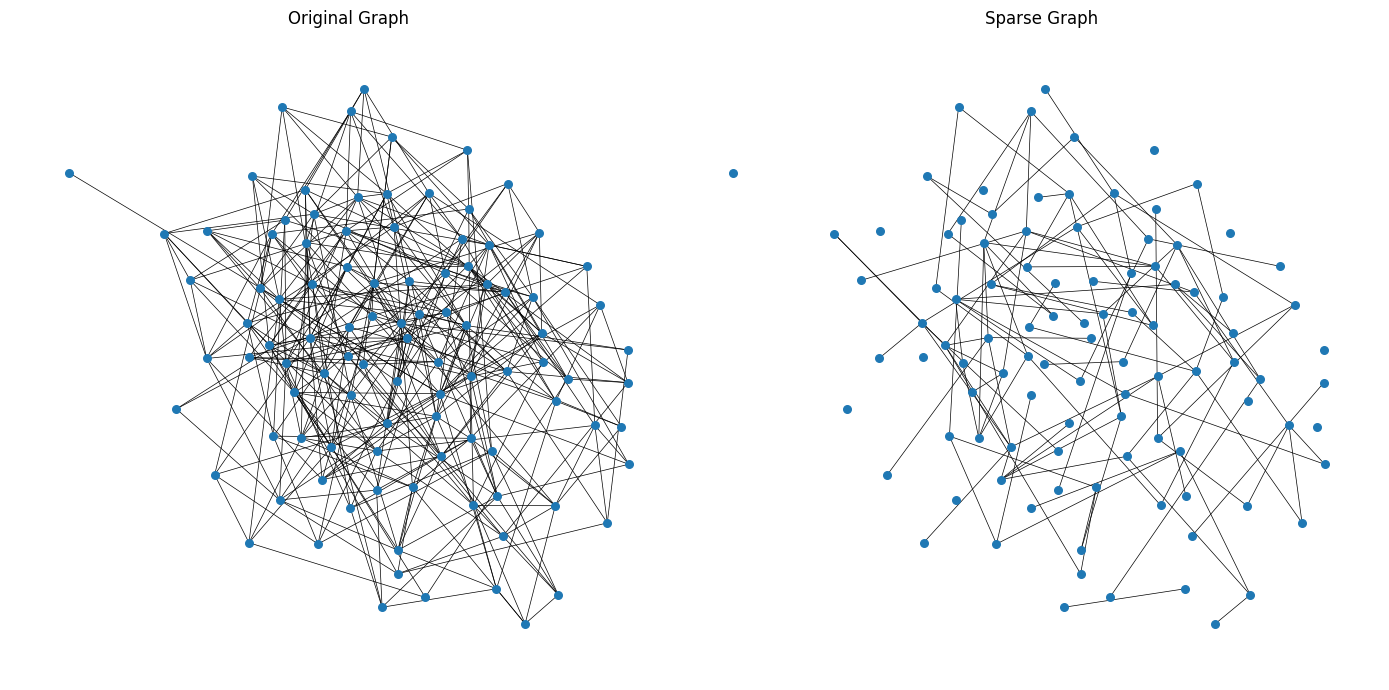

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# =========================
# パラメータ
# =========================
NUM_NODES = 100
EDGE_PROB = 0.08

SPARSIFY_RATIO = 0.3   # 残すエッジ割合

SEED = 42

random.seed(SEED)

# =========================
# 元グラフ生成
# =========================
G = nx.erdos_renyi_graph(
    n=NUM_NODES,
    p=EDGE_PROB,
    seed=SEED
)

print("=== Original Graph ===")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# =========================
# ランダム疎化
# =========================
edges = list(G.edges())

num_keep = int(len(edges) * SPARSIFY_RATIO)

sampled_edges = random.sample(edges, num_keep)

G_sparse = nx.Graph()
G_sparse.add_nodes_from(G.nodes())
G_sparse.add_edges_from(sampled_edges)

print("\n=== Sparse Graph ===")
print(f"Nodes: {G_sparse.number_of_nodes()}")
print(f"Edges: {G_sparse.number_of_edges()}")

# =========================
# 平均次数
# =========================
orig_avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
sparse_avg_degree = sum(dict(G_sparse.degree()).values()) / G_sparse.number_of_nodes()

print(f"\nOriginal Avg Degree : {orig_avg_degree:.2f}")
print(f"Sparse Avg Degree   : {sparse_avg_degree:.2f}")

# =========================
# 描画
# =========================
pos = nx.spring_layout(G, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 元グラフ
nx.draw(
    G,
    pos,
    ax=axes[0],
    node_size=30,
    width=0.5,
    with_labels=False
)

axes[0].set_title("Original Graph")

# 疎化グラフ
nx.draw(
    G_sparse,
    pos,
    ax=axes[1],
    node_size=30,
    width=0.5,
    with_labels=False
)

axes[1].set_title("Sparse Graph")

plt.tight_layout()
plt.show()